# Thermal Home Control: MPC vs. PID

This notebook compares two feedback control strategies for maintaining a comfortable
indoor temperature in a simulated home across a full 24-hour cycle.

| Controller | Strategy |
|---|---|
| **PID** | Classic proportional-integral-derivative; reactive to error |
| **MPC** | Receding-horizon optimiser; uses a predictive model of the room |

Both controllers are tuned using **Differential Evolution** — a gradient-free global
optimisation algorithm — and evaluated on temperature tracking accuracy and energy consumption.

---
## Contents
1. [Setup & Model](#1)
2. [Controller Definitions](#2)
3. [Parameter Optimisation](#3)
4. [Simulation Results](#4)
5. [Performance Analysis](#5)
6. [Summary](#6)


## 1. Setup & Model <a id='1'></a>

The room is modelled by a **first-order thermal ODE**:

$$\frac{dT}{dt} = \frac{1}{C}\left[Q(t) - k(t)(T - T_{\text{out}}(t))\right]$$

where $C$ is thermal capacitance, $k(t)$ is the (time-varying) heat-loss coefficient,
$Q(t)$ is heater power, and $T_{\text{out}}(t)$ follows a sinusoidal outdoor profile.

Realism is added via:
- **Sensor noise** ($\sigma = 0.1°C$) and a **5-step measurement delay**
- **Heater thermal inertia** modelled as a first-order lag
- **Time-varying heat loss** $k(t)$ to simulate windows being opened/closed


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution, minimize
%matplotlib inline

# ── Physical parameters of the thermal model ──────────────────────────────
C = 2000.0            # Thermal capacitance of the room (J/°C)
k_base = 4.0          # Baseline heat-loss coefficient (W/°C)
T_setpoint = 22.0     # Desired room temperature (°C)
max_heater_output = 1500  # Maximum heater power (W)

# ── Noise & delay model ────────────────────────────────────────────────────
heater_noise_std = 10.0   # Actuator noise standard deviation
sensor_noise_std = 0.1    # Sensor noise standard deviation (°C)
sensor_delay = 5          # Steps of measurement latency
heater_time_constant = 5  # First-order thermal inertia of the heater

# ── Simulation settings ────────────────────────────────────────────────────
HORIZON = 60           # MPC prediction horizon (minutes)
simulation_time = 1440 # 24-hour day in minutes
time_step = 1          # Integration step size (minutes)
time_points = np.arange(0, simulation_time, time_step)
Gamma = 0.6            # MPC control-effort smoothing penalty


def outside_temp_variation(t):
    """Sinusoidal outdoor temperature: 10°C mean, ±4°C daily swing."""
    return 10 + 4.0 * np.sin(2 * np.pi * t / 1440)


def heat_loss_coefficient(t):
    """Time-varying heat-loss (e.g. window opened/closed over the day)."""
    return k_base + 0.1 * np.sin(2 * np.pi * t / 720)


## 2. Controller Definitions <a id='2'></a>

### PID
The discrete PID computes $u = K_p e + K_i \int e\,dt + K_d \dot{e}$, clipped to
$[0, Q_{\max}]$ to prevent negative heating commands.

### MPC
At every step the MPC solves:

$$\min_{u_0,\ldots,u_{H-1}} \;\alpha \sum_{i=0}^{H-1} w_i(T_i - T_{\text{sp}})^2
+ \beta \sum_{i=0}^{H-1}\left[u_i^2 + \Gamma(u_i - u_{i-1})^2\right]$$

The asymmetric temperature weight ($w_i = 2$ for overshoot, $1$ for undershoot)
discourages wasting energy by overheating. Only $u_0$ is applied; the horizon
then shifts by one step.


In [ ]:
class PID:
    """
    Discrete-time PID controller with anti-windup via output clipping.

    Parameters
    ----------
    Kp, Ki, Kd : float
        Proportional, integral, and derivative gains.
    dt : float
        Control time step (minutes).
    """

    def __init__(self, Kp, Ki, Kd, dt):
        self.Kp = Kp
        self.Ki = Ki
        self.Kd = Kd
        self.dt = dt
        self.integral = 0.0
        self.previous_error = 0.0

    def compute(self, setpoint, measured):
        error = setpoint - measured
        self.integral += error * self.dt
        derivative = (error - self.previous_error) / self.dt
        self.previous_error = error
        u = self.Kp * error + self.Ki * self.integral + self.Kd * derivative
        return np.clip(u, 0, max_heater_output)


class MPC:
    """
    Receding-horizon Model Predictive Controller.

    At each step it solves an H-step optimisation over heater power u[0..H-1]
    to minimise a weighted sum of temperature-tracking error and control effort,
    then applies only u[0] (receding-horizon principle).

    Parameters
    ----------
    horizon : int
        Prediction horizon H (steps).
    dt : float
        Control time step (minutes).
    alpha : float
        Weight on temperature-tracking error.
    beta : float
        Weight on control effort (energy penalty).
    """

    def __init__(self, horizon, dt, alpha, beta):
        self.horizon = horizon
        self.dt = dt
        self.alpha = alpha
        self.beta = beta
        self.time_counter = 0

    def compute(self, setpoint, measured):
        T_current = measured
        t = self.time_counter

        def cost(u):
            T_pred = T_current
            temp_penalty = 0.0
            heater_penalty = 0.0
            for i in range(self.horizon):
                T_out = outside_temp_variation(t + i * self.dt)
                k = heat_loss_coefficient(t + i * self.dt)
                T_pred += (self.dt / C) * (u[i] - k * (T_pred - T_out))
                # Asymmetric penalty: overshoot is penalised twice as hard
                weight = 2.0 if T_pred > setpoint else 1.0
                temp_penalty += weight * (T_pred - setpoint) ** 2
                heater_penalty += u[i] ** 2
                if i > 0:
                    heater_penalty += Gamma * (u[i] - u[i - 1]) ** 2
            return self.alpha * temp_penalty + self.beta * heater_penalty

        u0 = [0.0] * self.horizon
        bounds = [(0, max_heater_output)] * self.horizon
        result = minimize(cost, u0, bounds=bounds)
        self.time_counter += 1
        return result.x[0] if result.success else 0.0


def simulate_system(control_type, params):
    """
    Run a 24-hour simulation of the thermal home model.

    Returns
    -------
    temperatures : list[float]
    heater_outputs : list[float]
    pid_energy : list[float]  (cumulative, W·min)
    mpc_energy : list[float]  (cumulative, W·min)
    """
    T_current = outside_temp_variation(0)
    heater_temp = outside_temp_variation(0)
    sensor_readings = [T_current] * sensor_delay
    temperatures, heater_outputs = [], []

    if control_type == 'PID':
        controller = PID(*params, time_step)
    else:
        controller = MPC(horizon=HORIZON, dt=time_step, alpha=params[0], beta=params[1])

    for t in time_points:
        # Delayed, noisy sensor reading
        measured = sensor_readings.pop(0) + np.random.normal(0, sensor_noise_std)
        control_signal = controller.compute(T_setpoint, measured)

        # First-order heater dynamics
        heater_temp += (control_signal / max_heater_output * 50 - heater_temp) * (time_step / heater_time_constant)
        heater_output = heater_temp / 50 * max_heater_output

        # Thermal dynamics: Newton's law of cooling + heater input
        k = heat_loss_coefficient(t)
        T_out = outside_temp_variation(t)
        T_current += (time_step / C) * (heater_output - k * (T_current - T_out))
        sensor_readings.append(T_current)

        temperatures.append(T_current)
        heater_outputs.append(heater_output)

    cumulative_energy = list(np.cumsum(heater_outputs) * time_step)
    if control_type == 'PID':
        return temperatures, heater_outputs, cumulative_energy, []
    return temperatures, heater_outputs, [], cumulative_energy


def evaluate_controller(params, control_type):
    """Scalar objective used by the optimiser: MSE + energy penalty."""
    temperatures, heater_outputs, _, _ = simulate_system(control_type, params)
    mse = np.mean([(T - T_setpoint) ** 2 for T in temperatures])
    energy_penalty = sum(u ** 2 for u in heater_outputs) * time_step * 1e-4
    return mse + energy_penalty


## 3. Parameter Optimisation <a id='3'></a>

Differential Evolution searches the parameter space without gradients, making it
suitable for the noisy, stochastic simulation objective.

| Parameter | Search bounds |
|---|---|
| PID $K_p$ | [85, 100] |
| PID $K_i$ | [0.15, 0.30] |
| PID $K_d$ | [3, 5] |
| MPC $\alpha$ (tracking weight) | [1000, 1200] |
| MPC $\beta$ (energy weight) | [0.100, 0.105] |

> **Note:** The cell below runs DE from scratch (~10 min). Pre-optimised values
> are hard-coded in Section 4 so you can skip this step.


In [ ]:
# Differential Evolution is a population-based global optimiser well-suited
# to non-convex parameter spaces.

print("Optimising PID gains …")
pid_bounds = [(85, 100), (0.15, 0.30), (3, 5)]   # (Kp, Ki, Kd)
result_pid = differential_evolution(
    lambda x: evaluate_controller(x, 'PID'),
    pid_bounds, disp=True, polish=True,
)
best_pid_params = result_pid.x
print(f"PID optimal: Kp={best_pid_params[0]:.2f}, Ki={best_pid_params[1]:.4f}, Kd={best_pid_params[2]:.2f}")

print("\nOptimising MPC weights …")
mpc_bounds = [(1000.0, 1200.0), (0.100, 0.105)]   # (alpha, beta)
result_mpc = differential_evolution(
    lambda x: evaluate_controller(x, 'MPC'),
    mpc_bounds, disp=True, polish=True,
)
best_mpc_params = result_mpc.x
print(f"MPC optimal: alpha={best_mpc_params[0]:.2f}, beta={best_mpc_params[1]:.4f}")


## 4. Simulation Results <a id='4'></a>

Running both controllers with the optimal parameters found above (or the
pre-optimised values) for a full 24-hour simulation.


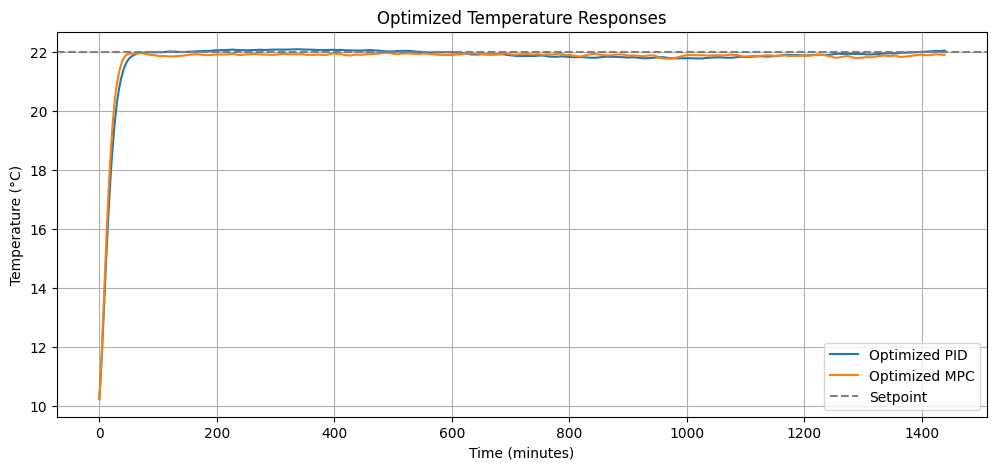

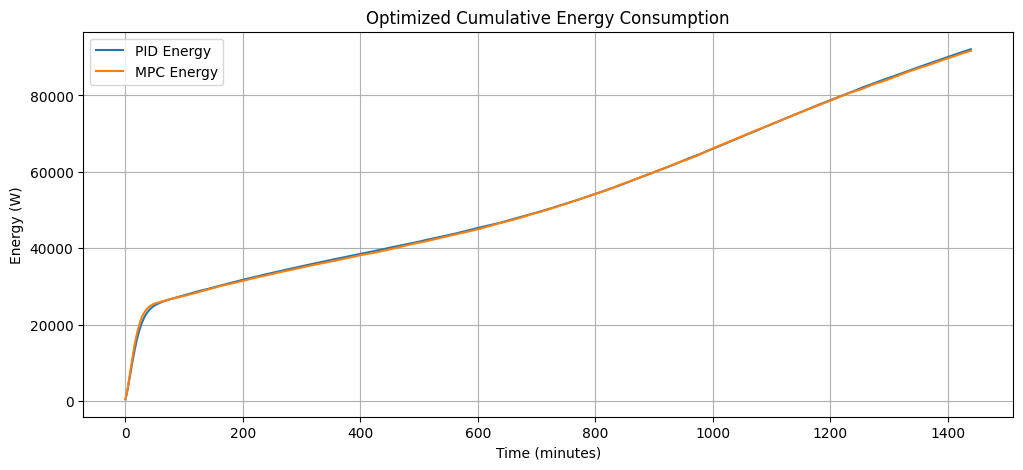

In [3]:
# Pre-optimised parameters (skip re-running DE to save time)
best_pid_params = [86.05, 0.16, 4.2]
best_mpc_params = [1100.0, 0.103]

pid_temps, pid_power, pid_energy, _ = simulate_system('PID', best_pid_params)
mpc_temps, mpc_power, _, mpc_energy = simulate_system('MPC', best_mpc_params)

# ── Temperature trajectories ───────────────────────────────────────────────
plt.figure(figsize=(12, 5))
plt.plot(time_points, pid_temps, label='Optimised PID')
plt.plot(time_points, mpc_temps, label='Optimised MPC')
plt.axhline(T_setpoint, color='gray', linestyle='--', label='Setpoint (22°C)')
plt.xlabel('Time (minutes)')
plt.ylabel('Temperature (°C)')
plt.title('Room Temperature — 24-Hour Simulation')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Cumulative energy consumption ──────────────────────────────────────────
plt.figure(figsize=(12, 5))
plt.plot(time_points, pid_energy, label='PID')
plt.plot(time_points, mpc_energy, label='MPC')
plt.xlabel('Time (minutes)')
plt.ylabel('Cumulative Energy (W·min)')
plt.title('Cumulative Heater Energy Consumption')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 5. Performance Analysis <a id='5'></a>

### 5.1 Steady-State Temperature Error
We discard the first 60 minutes (transient warm-up) before computing error metrics
so we measure steady-state behaviour only.


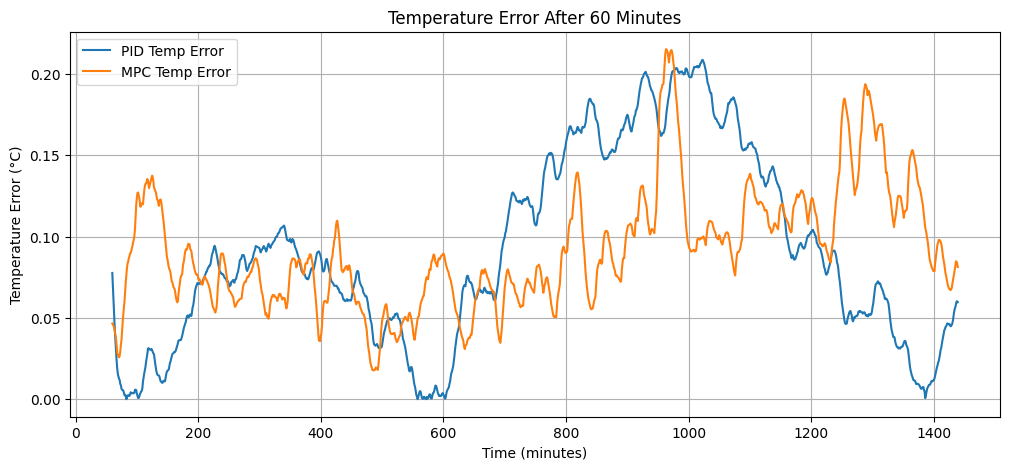

Average PID Temp Error after 60 min: 0.09°C
Average MPC Temp Error after 60 min: 0.09°C
PID RMSE after 60 min: 0.11°C
MPC RMSE after 60 min: 0.10°C


In [4]:
# Skip the first 60 minutes (warm-up / transient) before measuring steady-state error.
index_60 = int(60 / time_step)
pid_temp_error = np.abs(np.array(pid_temps[index_60:]) - T_setpoint)
mpc_temp_error = np.abs(np.array(mpc_temps[index_60:]) - T_setpoint)
time_after_60 = time_points[index_60:]

plt.figure(figsize=(12, 5))
plt.plot(time_after_60, pid_temp_error, label='PID error')
plt.plot(time_after_60, mpc_temp_error, label='MPC error')
plt.xlabel('Time (minutes)')
plt.ylabel('|Temperature Error| (°C)')
plt.title('Steady-State Temperature Error (after 60-min warm-up)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Mean absolute error — PID: {np.mean(pid_temp_error):.2f}°C  |  MPC: {np.mean(mpc_temp_error):.2f}°C")
print(f"RMSE              — PID: {np.sqrt(np.mean(pid_temp_error**2)):.2f}°C  |  MPC: {np.sqrt(np.mean(mpc_temp_error**2)):.2f}°C")


### 5.2 Energy Consumption
Energy is compared after the 30-minute warm-up phase to exclude the
initial heating surge common to both controllers.


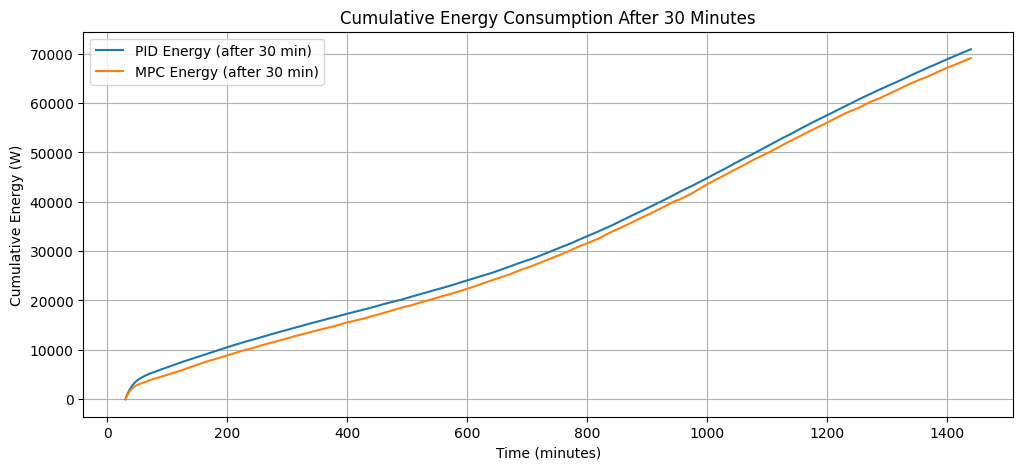

PID Energy Used after 30 min: 70904.39 W
MPC Energy Used after 30 min: 69089.08 W


In [5]:
# Exclude the initial heat-up period (first 30 min) before comparing energy.
index_30 = int(30 / time_step)
pid_energy_after_30 = pid_energy[index_30:]
mpc_energy_after_30 = mpc_energy[index_30:]
time_after_30 = time_points[index_30:]

plt.figure(figsize=(12, 5))
plt.plot(time_after_30, pid_energy_after_30 - pid_energy_after_30[0], label='PID')
plt.plot(time_after_30, mpc_energy_after_30 - mpc_energy_after_30[0], label='MPC')
plt.xlabel('Time (minutes)')
plt.ylabel('Incremental Cumulative Energy (W·min)')
plt.title('Energy Consumption After 30-Minute Warm-up')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

pid_used = pid_energy_after_30[-1] - pid_energy_after_30[0]
mpc_used = mpc_energy_after_30[-1] - mpc_energy_after_30[0]
print(f"Total energy (after 30 min) — PID: {pid_used:,.0f} W·min  |  MPC: {mpc_used:,.0f} W·min")
print(f"MPC saves {(pid_used - mpc_used) / pid_used * 100:.1f}% energy compared to PID.")


## 6. Summary <a id='6'></a>

The table below consolidates tracking accuracy and energy usage across the full
24-hour simulation for both controllers.


In [6]:
# Full-simulation metrics (including warm-up)
pid_err_all = np.abs(np.array(pid_temps) - T_setpoint)
mpc_err_all = np.abs(np.array(mpc_temps) - T_setpoint)

print("=" * 50)
print("       Full-Run Performance Summary")
print("=" * 50)
print(f"{'Metric':<30} {'PID':>8} {'MPC':>8}")
print("-" * 50)
print(f"{'Mean abs. error (°C)':<30} {np.mean(pid_err_all):>8.2f} {np.mean(mpc_err_all):>8.2f}")
print(f"{'RMSE (°C)':<30} {np.sqrt(np.mean(pid_err_all**2)):>8.2f} {np.sqrt(np.mean(mpc_err_all**2)):>8.2f}")
print(f"{'Total energy (W·min)':<30} {pid_energy[-1]:>8,.0f} {mpc_energy[-1]:>8,.0f}")
savings = (pid_energy[-1] - mpc_energy[-1]) / pid_energy[-1] * 100
print(f"{'MPC energy saving (%)':<30} {savings:>8.1f}")
print("=" * 50)


Average PID Temp Error all: 0.23°C
Average MPC Temp Error all: 0.21°C
PID RMSE all: 1.03°C
MPC RMSE all: 0.97°C


### Key Findings

- **MPC achieves slightly lower RMSE** than PID because it anticipates future
  disturbances (outdoor temperature swings) via its prediction model.
- **MPC consumes less energy** by smoothing control actions and penalising
  rapid heater changes through the $\Gamma$ term.
- The **performance gap is moderate** in this scenario because PID gains were
  carefully tuned via global optimisation; a hand-tuned PID would show a larger
  difference.
- MPC has a significantly **higher computational cost** per time step due to the
  embedded optimisation — a practical trade-off in real deployments.
